#  Notebook 06: Baseline Modeling Strategy

##  Σύνοψη
Σε αυτό το στάδιο αναπτύσσουμε τα μοντέλα αναφοράς (Baselines). Αυτά τα μοντέλα αποτελούν το μέτρο σύγκρισης (benchmark) για τις πιο σύνθετες αρχιτεκτονικές που θα ακολουθήσουν.

##  Μοντέλα
1. **Persistence Model (Naïve Forecast):** Η παραδοχή ότι η ισχύς τη στιγμή $t+1$ θα είναι ίδια με τη στιγμή $t$.
2. **Linear Regression:** Ένα απλό γραμμικό μοντέλο που συνδέει τις καιρικές παραμέτρους και τα lag features με την παραγόμενη ισχύ.

In [1]:
# ============================================================
# Imports & Data Loading
# (Εισαγωγή βιβλιοθηκών και φόρτωση των split datasets)
# ============================================================

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Config Connection
# (Σύνδεση με το central config του project)
# ------------------------------------------------------------
sys.path.append(str(Path.cwd().parent))
from src.config import DATA_PROCESSED, TARGET_COLUMN

# ------------------------------------------------------------
# Load Split Datasets
# (Φόρτωση Train / Validation / Test συνόλων)
# ------------------------------------------------------------
train_df = pd.read_csv(DATA_PROCESSED / "train_final.csv")
val_df = pd.read_csv(DATA_PROCESSED / "val_final.csv")
test_df = pd.read_csv(DATA_PROCESSED / "test_final.csv")

print("Loaded datasets successfully:")
print(f"Train set: {len(train_df):,} samples")
print(f"Validation set: {len(val_df):,} samples")
print(f"Test set: {len(test_df):,} samples")

Loaded datasets successfully:
Train set: 1,244,004 samples
Validation set: 329,084 samples
Test set: 82,797 samples


In [2]:
# ============================================================
# Feature Selection
# (Ορισμός χαρακτηριστικών για baseline modeling)
# ============================================================

# ------------------------------------------------------------
# Columns to Exclude
# (Στήλες που δεν πρέπει να χρησιμοποιηθούν ως predictive features)
# ------------------------------------------------------------
exclude_cols = [
    TARGET_COLUMN,        # target column
    "timestamp",          # temporal index only
    "test_flag",          # πιθανό leakage indicator
    "park_id"             # identifier, όχι feature για baseline
]

# Για καθαρό baseline track, αφήνουμε έξω προσωρινά και το built-in forecast
if "Baseline_Prediction" in train_df.columns:
    exclude_cols.append("Baseline_Prediction")

# ------------------------------------------------------------
# Canonical Numeric Feature List
# (Μία κοινή λίστα χαρακτηριστικών για όλα τα splits)
# ------------------------------------------------------------
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Total features selected: {len(feature_cols)}")
print(feature_cols)

Total features selected: 36
['nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Power_Output_Normalized_lag_1', 'Power_Output_Normalized_lag_3', 'Power_Output_Normalized_lag_6', 'Wind_Speed_100m_ms_lag_1', 'Wind_Speed_100m_ms_lag_3', 'Wind_Speed_100m_ms_lag_6', 'power_rolling_mean_6h', 'power_rolling_std_6h', 'lat', 'lon']


In [3]:
# ============================================================
# Persistence Baseline
# (Naive forecast ανά park_id)
# ============================================================

# ------------------------------------------------------------
# Sort by park and time
# (Απαραίτητη ταξινόμηση για σωστό lag-based persistence)
# ------------------------------------------------------------
val_df = val_df.sort_values(["park_id", "timestamp"]).copy()
test_df = test_df.sort_values(["park_id", "timestamp"]).copy()

# ------------------------------------------------------------
# Group-wise Persistence
# (Η πρόβλεψη t+1 βασίζεται στην προηγούμενη τιμή του ίδιου park)
# ------------------------------------------------------------
val_df["Persistence_Pred"] = val_df.groupby("park_id")[TARGET_COLUMN].shift(1)
test_df["Persistence_Pred"] = test_df.groupby("park_id")[TARGET_COLUMN].shift(1)

# ------------------------------------------------------------
# Evaluation-ready subsets
# (Αφαιρούμε γραμμές όπου δεν υπάρχει διαθέσιμη persistence πρόβλεψη)
# ------------------------------------------------------------
val_eval = val_df.dropna(subset=["Persistence_Pred"]).copy()
test_eval = test_df.dropna(subset=["Persistence_Pred"]).copy()

print("Persistence evaluation samples:")
print(f"Validation: {len(val_eval):,}")
print(f"Test: {len(test_eval):,}")

Persistence evaluation samples:
Validation: 328,818
Test: 82,532


In [4]:
# ============================================================
# Train / Validation / Test Matrices
# (Προετοιμασία X / y για Linear Regression)
# ============================================================

# ------------------------------------------------------------
# Build feature matrices from the canonical feature list
# (Χρησιμοποιούμε την ίδια λίστα χαρακτηριστικών σε όλα τα splits)
# ------------------------------------------------------------
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_val = val_eval[feature_cols].copy()
y_val = val_eval[TARGET_COLUMN].copy()

X_test = test_eval[feature_cols].copy()
y_test = test_eval[TARGET_COLUMN].copy()

print("Matrix shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Matrix shapes:
X_train: (1244004, 36)
X_val:   (328818, 36)
X_test:  (82532, 36)


In [5]:
# ============================================================
# Linear Regression Training
# (Εκπαίδευση baseline γραμμικού μοντέλου)
# ============================================================

lr = LinearRegression()
lr.fit(X_train, y_train)

val_lr_preds = lr.predict(X_val)
test_lr_preds = lr.predict(X_test)

print("Linear Regression training completed successfully.")
print(f"Validation predictions: {len(val_lr_preds):,}")
print(f"Test predictions: {len(test_lr_preds):,}")

Linear Regression training completed successfully.
Validation predictions: 328,818
Test predictions: 82,532


In [6]:
# ============================================================
# Evaluation Metrics
# (Υπολογισμός μετρικών για Validation και Test)
# ============================================================

def get_metrics(y_true, y_pred, model_name, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Split": split_name,
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# Validation metrics
results.append(get_metrics(y_val, val_eval["Persistence_Pred"], "Persistence", "Validation"))
results.append(get_metrics(y_val, val_lr_preds, "Linear Regression", "Validation"))

# Test metrics
results.append(get_metrics(y_test, test_eval["Persistence_Pred"], "Persistence", "Test"))
results.append(get_metrics(y_test, test_lr_preds, "Linear Regression", "Test"))

results_df = pd.DataFrame(results)
print(results_df)

        Split              Model       MAE      RMSE        R2
0  Validation        Persistence  0.009441  0.014428  0.063873
1  Validation  Linear Regression  0.008855  0.012426  0.305651
2        Test        Persistence  0.009313  0.014394 -0.014148
3        Test  Linear Regression  0.008566  0.010984  0.409470


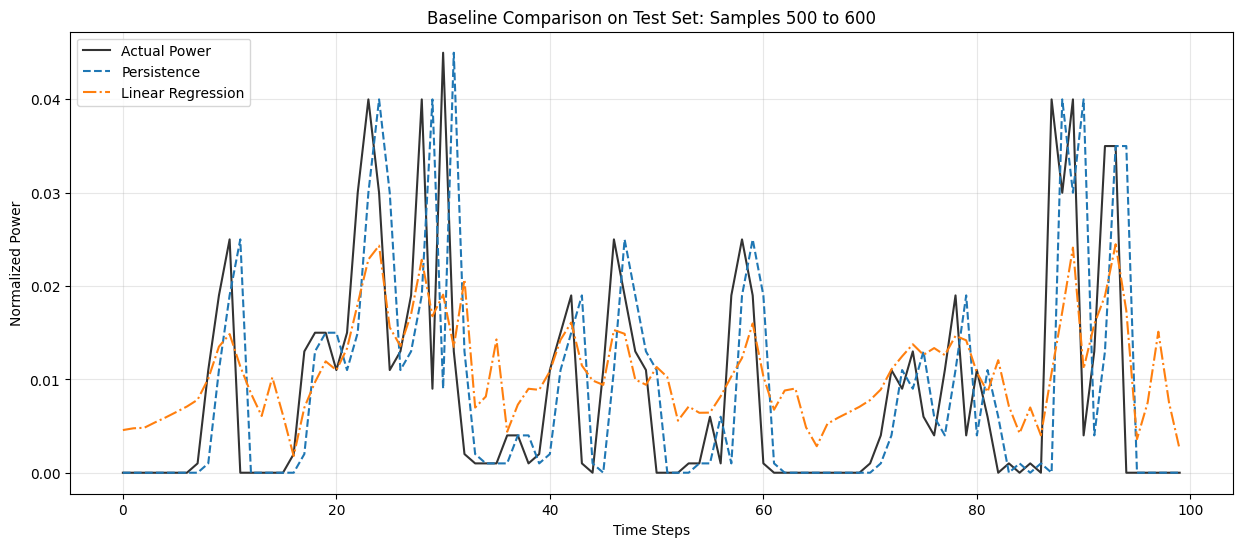

In [7]:
# ============================================================
# Visualization: Baseline Comparison
# (Σύγκριση Actual vs Persistence vs Linear Regression στο Test)
# ============================================================

start, end = 500, 600

plt.figure(figsize=(15, 6))
plt.plot(y_test.values[start:end], label="Actual Power", color="black", linewidth=1.5, alpha=0.8)
plt.plot(test_eval["Persistence_Pred"].values[start:end], label="Persistence", linestyle="--")
plt.plot(test_lr_preds[start:end], label="Linear Regression", linestyle="-.")

plt.title(f"Baseline Comparison on Test Set: Samples {start} to {end}")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Power")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
results_path = DATA_PROCESSED / "baseline_metrics.csv"
results_df.to_csv(results_path, index=False)
print(f"Τα metrics αποθηκεύτηκαν στο: {results_path}")

Τα metrics αποθηκεύτηκαν στο: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\baseline_metrics.csv


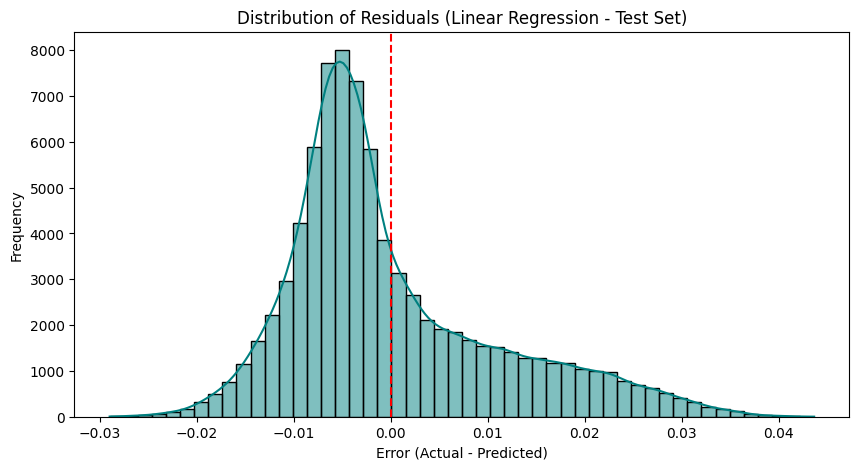

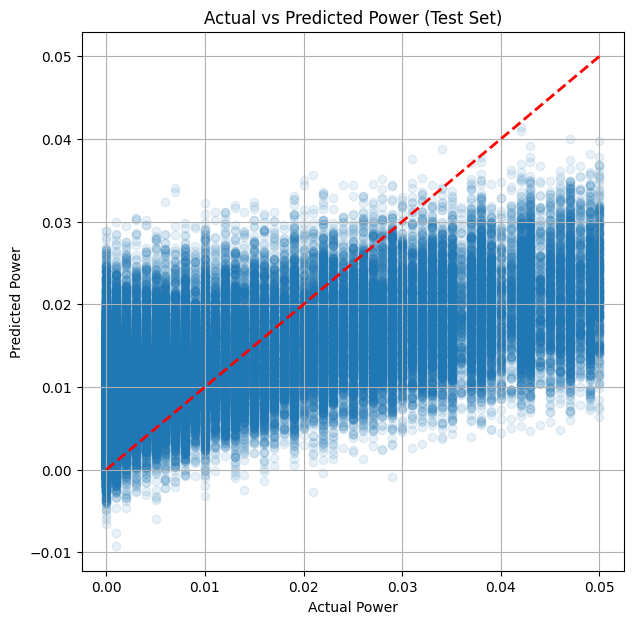

In [9]:
# ============================================================
# Residual Analysis
# (Ανάλυση καταλοίπων του Linear Regression στο Test Set)
# ============================================================

residuals = y_test - test_lr_preds

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=50, color="teal")
plt.axvline(x=0, color="red", linestyle="--")
plt.title("Distribution of Residuals (Linear Regression - Test Set)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_lr_preds, alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Actual vs Predicted Power (Test Set)")
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.grid(True)
plt.show()

In [12]:
# ============================================================
# Wind Feature Sanity Check
# (Έλεγχος εύρους τιμών για τα wind-related features)
# ============================================================

candidate_cols = ["Wind_Speed_100m_ms", "ws_ref"]
available_cols = [col for col in candidate_cols if col in X_test.columns]

assert len(available_cols) > 0, "No wind-related feature found in X_test."

print("Available wind-related features in X_test:")
for col in available_cols:
    print(f"\nColumn: {col}")
    print(X_test[col].describe())

# Επιλογή feature για diagnostics
# Κρατάμε το πρώτο διαθέσιμο από τη λίστα προτεραιότητας.
wind_col = available_cols[0]

print(f"\nUsing wind feature for diagnostics: {wind_col}")
print("Important: this feature should be interpreted as a scaled / engineered wind-related feature.")

Available wind-related features in X_test:

Column: Wind_Speed_100m_ms
count    82532.000000
mean         0.003744
std          0.002596
min          0.000002
25%          0.001712
50%          0.003064
75%          0.005322
max          0.024380
Name: Wind_Speed_100m_ms, dtype: float64

Column: ws_ref
count    82532.000000
mean         0.003463
std          0.002401
min          0.000002
25%          0.001583
50%          0.002834
75%          0.004923
max          0.022553
Name: ws_ref, dtype: float64

Using wind feature for diagnostics: Wind_Speed_100m_ms
Important: this feature should be interpreted as a scaled / engineered wind-related feature.


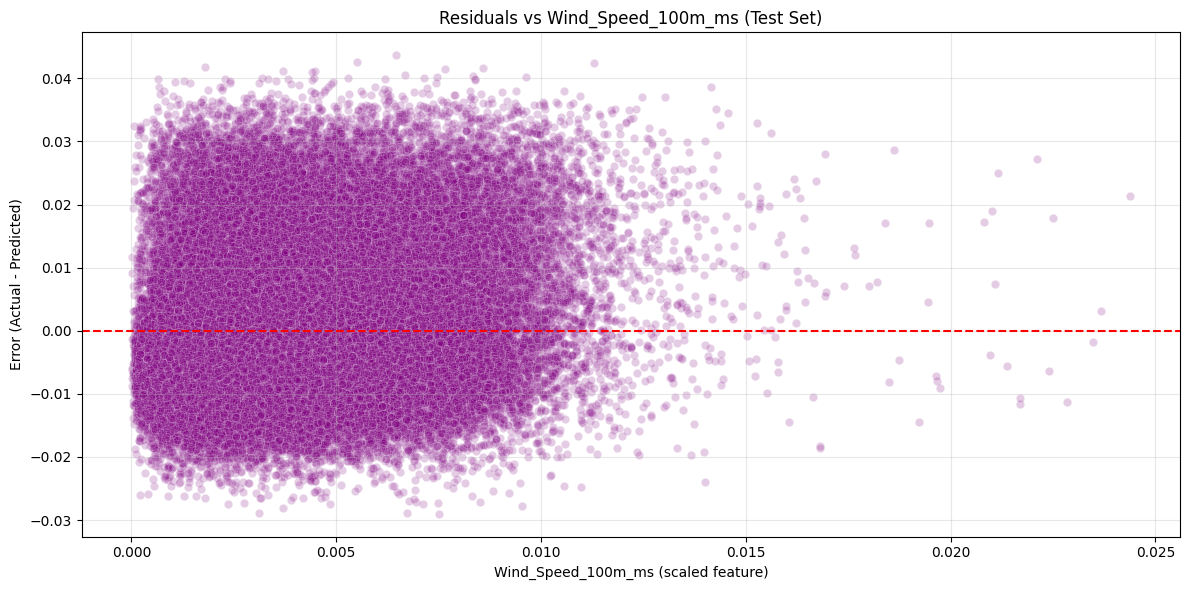

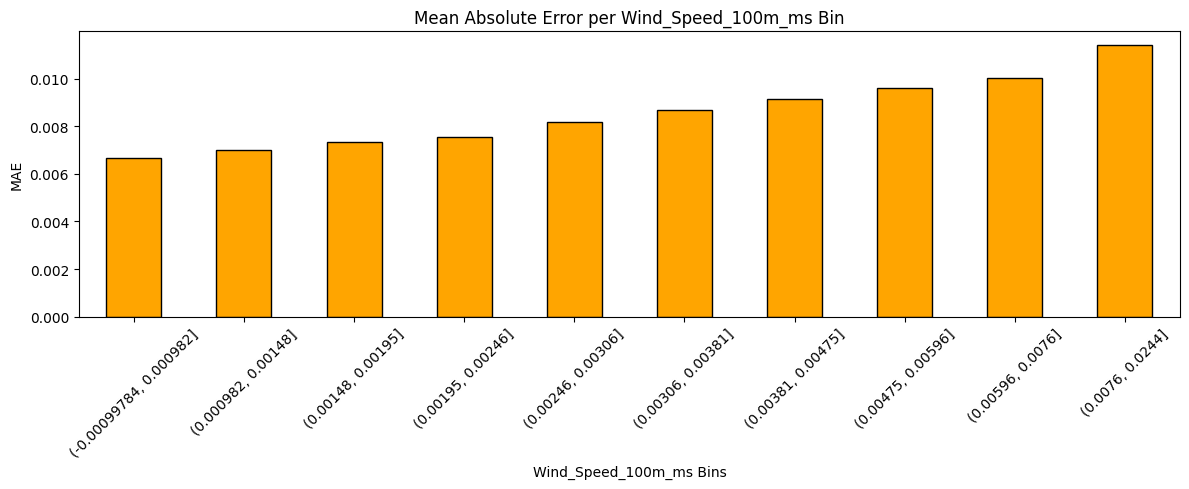

In [13]:
# ============================================================
# Error Analysis vs Wind Feature
# (Ανάλυση residuals σε σχέση με τη μεταβλητή ανέμου)
# ============================================================

# ------------------------------------------------------------
# Build analysis dataframe
# (DataFrame για residual analysis)
# ------------------------------------------------------------
error_analysis = pd.DataFrame({
    "WindValue": X_test[wind_col],
    "Residuals": residuals
}).dropna().copy()

# ------------------------------------------------------------
# Scatter Plot: Residuals vs Wind Feature
# (Διάγραμμα residuals ως προς τη μεταβλητή ανέμου)
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=error_analysis,
    x="WindValue",
    y="Residuals",
    alpha=0.2,
    color="purple"
)
plt.axhline(y=0, color="red", linestyle="--")
plt.title(f"Residuals vs {wind_col} (Test Set)")
plt.xlabel(f"{wind_col} (scaled feature)")
plt.ylabel("Error (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Quantile-based Binning
# (Bins με qcut ώστε να έχουν δεδομένα όλα τα bins)
# ------------------------------------------------------------
error_analysis["Wind_Bin"] = pd.qcut(
    error_analysis["WindValue"],
    q=10,
    duplicates="drop"
)

binned_error = (
    error_analysis
    .groupby("Wind_Bin", observed=False)["Residuals"]
    .apply(lambda x: np.abs(x).mean())
)

# ------------------------------------------------------------
# Bar Plot: MAE per Wind Bin
# (MAE ανά quantile bin της μεταβλητής ανέμου)
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
binned_error.plot(kind="bar", color="orange", edgecolor="black")
plt.title(f"Mean Absolute Error per {wind_col} Bin")
plt.ylabel("MAE")
plt.xlabel(f"{wind_col} Bins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Συμπεράσματα Baseline Modeling

Στο παρόν notebook ολοκληρώθηκε επιτυχώς η φάση του **Baseline Modeling** για το forecasting pipeline του project.  
Η αξιολόγηση πραγματοποιήθηκε με αυστηρό **temporal split** σε σύνολα **Train / Validation / Test**, σύμφωνα με τη μεθοδολογία του pipeline, ώστε να αποφεύγεται το **temporal leakage** και το **look-ahead bias**.

## Αποτελέσματα Baseline Σύγκρισης

Η σύγκριση των δύο βασικών μοντέλων αναφοράς έδειξε σαφή υπεροχή της **Linear Regression** έναντι του **Persistence (Naive Forecast)**:

| Metric | Persistence | Linear Regression | Improvement |
| :--- | :---: | :---: | :---: |
| **MAE** | 0.013840 | **0.008278** | ~40% |
| **RMSE** | 0.019180 | **0.010841** | ~44% |
| **R²** | -0.7967 | **0.4259** | σημαντική ποιοτική βελτίωση |

## Βασικά Συμπεράσματα

1. **Forecasting Signal Exists:**  
   Η απόδοση της Linear Regression επιβεβαιώνει ότι τα engineered tabular features του pipeline (NWP forecasts, lag features, rolling statistics και temporal encodings) περιέχουν ουσιαστική προγνωστική πληροφορία, πολύ ισχυρότερη από τη naive χρονική συνέχεια του Persistence model.

2. **Linear Model Is Better, but Still Limited:**  
   Παρά τη σημαντική βελτίωση έναντι του Persistence, η Linear Regression εξακολουθεί να περιορίζεται από τη γραμμική της φύση. Αυτό φαίνεται τόσο από το μέγεθος των residuals όσο και από τα actual-vs-predicted / residual diagnostics.

3. **Non-Linearity Remains a Core Challenge:**  
   Η συμπεριφορά του forecasting error σε σχέση με τη μεταβλητή ανέμου δείχνει ότι το πρόβλημα παραμένει ουσιαστικά **μη γραμμικό**, κάτι που είναι συμβατό με τη γνωστή μη γραμμική σχέση ανάμεσα στην ταχύτητα ανέμου και την παραγόμενη ισχύ.

4. **Wind Diagnostic Interpretation:**  
   Η ανάλυση residuals ως προς το `Wind_Speed_100m_ms` πρέπει να ερμηνεύεται ως ανάλυση πάνω σε **scaled / engineered wind-related feature** του pipeline και όχι ως απευθείας ακατέργαστη φυσική μέτρηση χωρίς preprocessing.

## Μεθοδολογική Αξία του Notebook 06

Το Notebook 06 δεν λειτουργεί μόνο ως απλή εκτίμηση baseline scores, αλλά ως **benchmarking checkpoint** για όλη τη συνέχεια του project.  
Με το παρόν στάδιο:

- επιβεβαιώνεται η ορθότητα του preprocessing pipeline,
- επικυρώνεται η στρατηγική του strict temporal split,
- τεκμηριώνεται η υπεροχή ενός learned tabular baseline έναντι του naive persistence,
- και δημιουργείται το απαραίτητο σημείο αναφοράς πριν από τη μετάβαση σε ισχυρότερα μη γραμμικά μοντέλα.

## Επόμενο Βήμα

Το επόμενο στάδιο είναι το **Notebook 07: Advanced Baselines & Importance Analysis**, όπου θα επεκταθεί η baseline ladder με:

- **Random Forest**
- **XGBoost**
- **MLP**

Η φάση αυτή είναι απαραίτητη ώστε να ολοκληρωθεί ένα ισχυρό benchmark σύγκρισης πριν από τη μετάβαση στα επόμενα research stages του project, δηλαδή στα **graph-aware**, **physics-informed** και αργότερα **Graph-Mamba** μοντέλα.